# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [10]:
# Створюємо таблицю для курсів валют (сучасний спосіб)
def create_currency_table(engine):
    """Створює таблицю через SQLAlchemy"""

    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        # тут лише одна транзакція - conn.begin() не треба
        conn.execute(create_table_sql)

    print("✅ Таблиця currency_rates створена")

def fetch_exchange_rates():
    """Отримує курси валют з API"""
    try:
        # Безкоштовний API курсів валют
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        # Валюти що нас цікавлять
        currencies = ['USD', 'EUR', 'GBP', 'UAH', 'PLN', 'JPY']
        rates = {}

        for currency in currencies:
            if currency in data['rates']:
                # Зберігаємо курс до USD (скільки одиниць валюти за 1 USD)
                rates[currency] = data['rates'][currency]

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):
    """Зберігає курси в БД з обробкою конфліктів"""

    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    # SQL з ON DUPLICATE KEY UPDATE для MySQL
    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.connect() as conn:
            with conn.begin():  # Транзакція для всіх вставок
                for currency, rate in rates_dict.items():
                    conn.execute(insert_sql, {
                        'currency': currency,
                        'rate': rate,
                        'date': rate_date
                    })

        print(f"✅ Збережено {len(rates_dict)} курсів валют на {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

In [13]:
# Виконуємо повний цикл API → БД
create_currency_table(engine)

print("📡 Отримуємо курси валют...")
rates, date = fetch_exchange_rates()

if rates:
    print(f"Отримані курси на {date}:")
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо в БД
    if save_exchange_rates(engine, rates, date):
        # Перевіряємо збережені дані
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )
        print("\nЗбережені дані:")
        display(verification_df)

✅ Таблиця currency_rates створена
📡 Отримуємо курси валют...
Отримані курси на 2026-03-15:
  1 USD = 1.0000 USD
  1 USD = 0.8730 EUR
  1 USD = 0.7540 GBP
  1 USD = 44.1700 UAH
  1 USD = 3.7300 PLN
  1 USD = 159.5000 JPY
✅ Збережено 6 курсів валют на 2026-03-15

Збережені дані:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,6,USD,1.000,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
1,7,EUR,0.873,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
2,8,GBP,0.754,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
3,9,UAH,44.170,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
4,10,PLN,3.730,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
5,11,JPY,159.500,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:33:07
6,1,EUR,0.874,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
7,2,GBP,0.755,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
8,3,UAH,44.170,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
9,4,PLN,3.730,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50


In [12]:
pd.read_sql("SELECT * FROM currency_rates", engine)

,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,EUR,0.874,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
1,2,GBP,0.755,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
2,3,UAH,44.170,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
3,4,PLN,3.730,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
4,5,JPY,159.540,2026-03-14,2026-03-14 22:21:50,2026-03-14 22:21:50
5,6,USD,1.000,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:30:43
6,7,EUR,0.873,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:30:43
7,8,GBP,0.754,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:30:43
8,9,UAH,44.170,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:30:43
9,10,PLN,3.730,2026-03-15,2026-03-15 23:30:43,2026-03-15 23:30:43


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без фукнції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

Extract (Витягування даних):¶
дані про виконані замовлення за 2004 рік - з'єднати таблиці orders, orderdetails, products, customers


In [14]:
sales_query = """
SELECT
    o.orderNumber,
    o.orderDate,
    c.customerName,
    c.country,
    od.productCode,
    od.quantityOrdered,
    od.priceEach,
    (od.quantityOrdered * od.priceEach) as total_amount,
    p.buyPrice,
    p.productLine
FROM orders o
JOIN orderdetails od ON o.orderNumber = od.orderNumber
JOIN customers c ON o.customerNumber = c.customerNumber
JOIN products p ON od.productCode = p.productCode
WHERE YEAR(o.orderDate) = 2004
"""

df_sales = pd.read_sql(sales_query, engine, parse_dates=['orderDate'])

Extract (Витягування даних):¶
дані про продукти - назви, категорії, ціни

In [15]:
df_products = pd.read_sql("""
SELECT productName, productLine, buyPrice, MSRP
FROM products
""", engine)

Extract (Витягування даних):¶
дані про курси валют - використати дані з попереднього завдання

In [16]:
df_rates = pd.read_sql("""
SELECT * FROM currency_rates
""", engine)

eur_rate = df_rates[df_rates["currency_code"]=="EUR"].iloc[-1]["rate_to_usd"]

Transform (Обробка даних):
2.1 Додати розрахункові колонки до основної таблиці:

In [17]:
df_sales["profit_per_item"] = df_sales["priceEach"] - df_sales["buyPrice"]
df_sales["total_profit"] = df_sales["profit_per_item"] * df_sales["quantityOrdered"]
df_sales["total_amount_eur"] = df_sales["total_amount"] / eur_rate

Transform (Обробка даних):
2.2 Створити аналітичну таблицю по країнах (ТОП-5):

In [18]:
top_countries = (
    df_sales
    .groupby("country")
    .agg(
        orders=("orderNumber","nunique"),
        revenue=("total_amount","sum"),
        profit=("total_profit","sum"),
        items=("quantityOrdered","sum")
    )
)

top_countries["margin_%"] = (top_countries["profit"] / top_countries["revenue"]) * 100
top_countries = top_countries.sort_values("revenue", ascending=False).head(5)

Transform (Обробка даних):
2.3 Створити аналітичну таблицю по продуктових лініях:

In [19]:
product_lines = (
    df_sales
    .groupby("productLine")
    .agg(
        orders=("orderNumber","nunique"),
        revenue=("total_amount","sum"),
        profit=("total_profit","sum"),
        items=("quantityOrdered","sum")
    )
)

product_lines["margin_%"] = (product_lines["profit"] / product_lines["revenue"]) * 100
product_lines = product_lines.sort_values("revenue", ascending=False)

Transform (Обробка даних):
2.4 Створити підсумкову інформацію (Executive Summary):¶

In [20]:
summary = {
    "Total revenue USD": df_sales["total_amount"].sum(),
    "Total revenue EUR": df_sales["total_amount_eur"].sum(),
    "Total profit USD": df_sales["total_profit"].sum(),
    "Profit margin %": (df_sales["total_profit"].sum() / df_sales["total_amount"].sum()) * 100,
    "Avg order size": df_sales["total_amount"].mean(),
    "Unique orders": df_sales["orderNumber"].nunique(),
    "Unique customers": df_sales["customerName"].nunique(),
    "Period start": df_sales["orderDate"].min(),
    "Period end": df_sales["orderDate"].max(),
    "Top country": top_countries.index[0],
    "Top product line": product_lines.index[0]
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric","Value"])

Load (Збереження результатів):¶
3.1 Excel файл з трьома вкладками:
"Summary" - підсумкова інформація у вигляді таблиці "Показник - Значення"
"Top_Countries" - аналітика по топ-5 країнах
"Product_Lines" - аналітика по всіх продуктових лініях


In [32]:
with pd.ExcelWriter("classicmodels_report.xlsx") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    top_countries.to_excel(writer, sheet_name="Top_Countries")
    product_lines.to_excel(writer, sheet_name="Product_Lines")


Load (Збереження результатів):¶
3.2 Візуалізація:
Створіть стовпчикову діаграму топ-5 країн за доходом.
Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

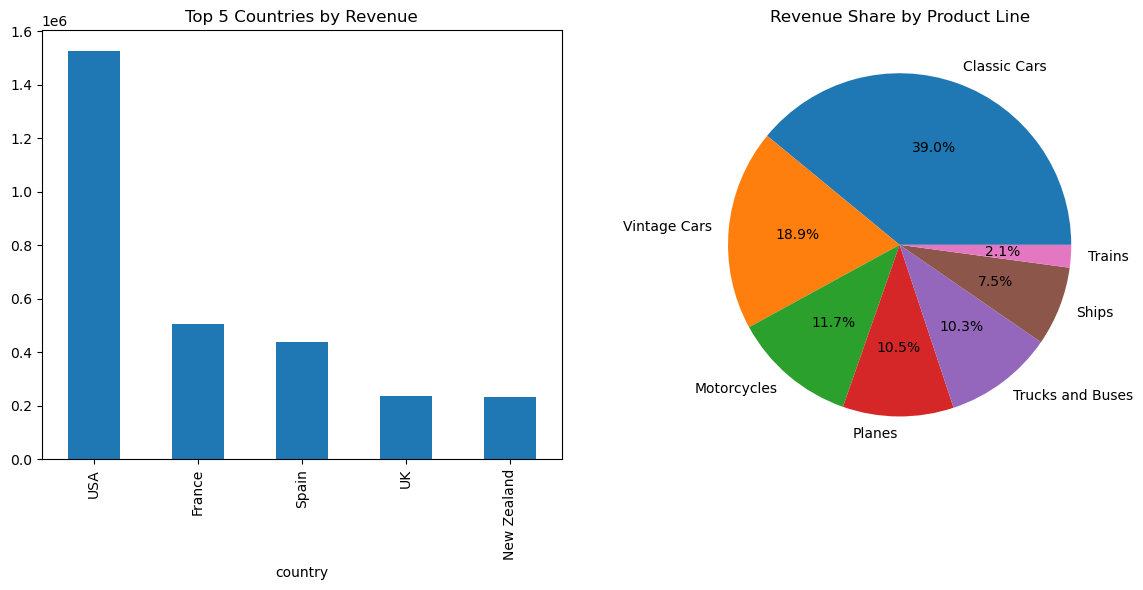

In [34]:
    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    top_countries["revenue"].plot(
        kind="bar",
        ax=axes[0],
        title="Top 5 Countries by Revenue"
    )
    product_lines["revenue"].plot(
        kind="pie",
        ax=axes[1],
        autopct="%1.1f%%",
        title="Revenue Share by Product Line"
    )
    axes[1].set_ylabel("") 
    plt.tight_layout()
    plt.show()